# Partie 4 — Analyse exploratoire croisée sentiment / marché

**Période :** janvier 2020 → mars 2022 · **Univers :** AAPL, AMZN, META, NVDA, TSLA
**Corpus :** ~3,7 millions de messages StockTwits horodatés, scorés par FinBERT
**Panel :** 2 740 observations (5 tickers × 548 jours de bourse), 76 colonnes

---

## Pourquoi cette partie existe

La première version de ce travail utilisait un corpus 2023-2026 et cherchait à prédire le rendement de
séance. Les résultats étaient nuls (MCC = 0.026, AUC = 0.516). Deux causes ont été identifiées :

| Cause | Diagnostic | Correction apportée ici |
|---|---|---|
| **Densité du corpus** | médiane de 2 messages par jour et par titre → la moyenne de sentiment était du bruit d'échantillonnage pur | corpus StockTwits 2020-2022 : **170 à 1 474 messages par nuit** |
| **Cible mal choisie** | on prédisait la séance, alors que l'information nocturne est absorbée à l'ouverture | on décompose le rendement et on teste **chaque morceau séparément** |

Cette partie 4 sert à **choisir la cible avant de modéliser**. On ne construit aucun modèle ici : on
mesure où le signal se trouve, et on prouve qu'il n'y a pas de fuite d'information.

---

## Structure du notebook

| § | Question posée | Sortie |
|---|---|---|
| **1** | Que contient exactement le panel ? | anatomie des 76 colonnes |
| **2** | À quoi ressemblent les données ? | statistiques descriptives |
| **3** | Le corpus est-il assez dense cette fois ? | distribution du nombre de messages |
| **4** | Prix et sentiment bougent-ils ensemble ? | séries temporelles superposées |
| **5** | Quelles corrélations sont **exploitables** ? | tableau avec colonne STATUT |
| **6** | L'effet est-il monotone et présent sur les 5 titres ? | analyse par quintiles |
| **7** | L'effet est-il statistiquement solide ? | z-test, bootstrap par blocs, Spearman |
| **8** | Le signal est-il bien orienté dans le temps ? | lags positifs **et négatifs** |
| **9** | L'attention prédit-elle le risque ? | incrément de R² sur l'amplitude |
| **10** | L'effet tient-il dans tous les régimes ? | découpage 2020-2022 |
| **11** | Que retenir pour la partie 5 ? | conclusion et figure principale |

---

## Les trois cibles — à connaître par cœur pour la soutenance

Une journée boursière se décompose en **deux morceaux distincts**, et c'est toute la thèse de ce mémoire :

```
   16h00 (J−1)                 9h30 (J)                        16h00 (J)
        │                          │                                │
        │◄──── MARCHÉ FERMÉ ──────►│◄────── MARCHÉ OUVERT ────────►│
        │       (le « gap »)       │          (la « séance »)       │
     Close(J−1)                 Open(J)                         Close(J)
```

| Cible | Formule | Ce qu'elle mesure |
|---|---|---|
| `gap` | `Open(J) / Close(J−1) − 1` | le saut de prix **pendant la fermeture** — personne ne peut trader pendant qu'il se forme |
| `ret_oc` | `Close(J) / Open(J) − 1` | le rendement **pendant la séance** — c'est là que le marché est liquide et actif |
| `ret_cc` | `Close(J) / Close(J−1) − 1` | le total : `(1 + gap) × (1 + ret_oc) − 1` |

Et six **fenêtres de sentiment**, définies par l'heure de publication des messages :

| Fenêtre | Heures couvertes | Se ferme à |
|---|---|---|
| `overnight` | 16h00 (J−1) → 00h00 | minuit |
| `pre` | 00h00 → 09h30 | l'ouverture |
| `night_full` | = `overnight` + `pre` réunis | l'ouverture |
| `open30` | 09h30 → 10h00 | 10h00 |
| `mkt` | 10h00 → 16h00 | la clôture |
| `post` | 16h00 → 00h00 | minuit |

> **La règle qui gouverne toute la partie 4 :** une fenêtre de texte ne peut servir à prédire une cible que
> si elle **se ferme avant que la cible ne commence à se former**. Toute corrélation qui viole cette règle
> mesure une réaction, pas une prédiction.

---
# §1 — Chargement et anatomie du panel

On commence par regarder ce qu'on a. Le panel est **équilibré** : chaque ticker a exactement le même
nombre de jours, donc aucun titre ne pèse plus lourd qu'un autre dans les statistiques globales.

In [1]:
# ============================================================================
#  CONFIGURATION — LA SEULE LIGNE À MODIFIER SI TU CHANGES DE MACHINE
# ============================================================================
PROJET = r"C:\Users\semy4\OneDrive\Bureau\Fintech_project"

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr

DATA = os.path.join(PROJET, "data", "processed")
DOCS = os.path.join(PROJET, "docs")
os.makedirs(DOCS, exist_ok=True)

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
plt.style.use("seaborn-v0_8-whitegrid")

PANEL = os.path.join(DATA, "PANEL_SENTIMENT_WINDOWS_2020_2022_v2.csv")

df = pd.read_csv(PANEL)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Fichier   : {PANEL}")
print(f"Dimension : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Période   : {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Tickers   : {sorted(df['Ticker'].unique())}")
print(f"\nJours de bourse par ticker :")
print(df.groupby("Ticker")["Date"].nunique().to_string())
print(f"\nPanel équilibré : {df.groupby('Ticker')['Date'].nunique().nunique() == 1}")

Fichier   : C:\Users\semy4\OneDrive\Bureau\Fintech_project\data\processed\PANEL_SENTIMENT_WINDOWS_2020_2022_v2.csv
Dimension : 2,740 lignes x 81 colonnes
Période   : 2020-01-02 -> 2022-03-04
Tickers   : ['AAPL', 'AMZN', 'META', 'NVDA', 'TSLA']

Jours de bourse par ticker :
Ticker
AAPL    548
AMZN    548
META    548
NVDA    548
TSLA    548

Panel équilibré : True


### Les 81 colonnes, rangées par famille

Le panel n'est pas un tableau plat : c'est **six blocs de variables** qui répondent chacun à une question
différente. Cette cellule les classe automatiquement — c'est la carte qu'il faut avoir en tête.

In [2]:
FAMILLES = {
    "Identité"          : ["Date", "Ticker"],
    "Prix bruts (OHLCV)": ["Open", "High", "Low", "Close", "Volume"],
    "Prix dérivés"      : ["prev_close", "prev_volume", "prev_ret_cc", "vol_20d",
                           "gap", "ret_oc", "ret_cc"],
    "Cibles binaires"   : ["y_gap", "y_oc", "y_cc"],
}
FENETRES = ["overnight", "pre", "night_full", "open30", "mkt", "post"]

deja = set(sum(FAMILLES.values(), []))
for f in FENETRES:
    cols = [c_ for c_ in df.columns if c_.endswith("_" + f) and c_ not in deja]
    FAMILLES[f"Sentiment — {f}"] = cols
    deja |= set(cols)

FAMILLES["Dérivées / décalées"] = [c_ for c_ in df.columns if c_ not in deja]

total = 0
for nom, cols in FAMILLES.items():
    cols = [c_ for c_ in cols if c_ in df.columns]
    total += len(cols)
    print(f"{nom:24s} ({len(cols):2d}) : {', '.join(cols)}")
print(f"\nTotal classé : {total} / {df.shape[1]} colonnes")

Identité                 ( 2) : Date, Ticker
Prix bruts (OHLCV)       ( 5) : Open, High, Low, Close, Volume
Prix dérivés             ( 7) : prev_close, prev_volume, prev_ret_cc, vol_20d, gap, ret_oc, ret_cc
Cibles binaires          ( 3) : y_gap, y_oc, y_cc
Sentiment — overnight    ( 7) : n_overnight, mu_overnight, sd_overnight, p10_overnight, p90_overnight, pos_overnight, neg_overnight
Sentiment — pre          ( 7) : n_pre, mu_pre, sd_pre, p10_pre, p90_pre, pos_pre, neg_pre
Sentiment — night_full   (10) : n_night_full, mu_night_full, sd_night_full, p10_night_full, p90_night_full, pos_night_full, neg_night_full, nlog_night_full, nabn_night_full, disp_night_full
Sentiment — open30       (10) : n_open30, mu_open30, sd_open30, p10_open30, p90_open30, pos_open30, neg_open30, nlog_open30, nabn_open30, disp_open30
Sentiment — mkt          (10) : n_mkt, mu_mkt, sd_mkt, p10_mkt, p90_mkt, pos_mkt, neg_mkt, nlog_mkt, nabn_mkt, disp_mkt
Sentiment — post         (10) : n_post, mu_post, sd_post, p10

### Vérifier les identités comptables — le premier réflexe

Avant toute analyse, on vérifie que les colonnes dérivées sont bien ce qu'elles prétendent être. Trois
identités doivent être vraies **à la précision machine près**. Si l'une échoue, il y a une erreur de
construction et tout ce qui suit est faux.

1. `gap = Open / prev_close − 1`
2. `ret_oc = Close / Open − 1`
3. `(1 + gap) × (1 + ret_oc) = 1 + ret_cc` ← la décomposition du rendement quotidien

C'est aussi la démonstration la plus simple à faire au tableau le jour de la soutenance.

In [3]:
ctrl = df.dropna(subset=["prev_close", "gap", "ret_oc", "ret_cc"]).copy()

e1 = (ctrl["Open"] / ctrl["prev_close"] - 1 - ctrl["gap"]).abs().max()
e2 = (ctrl["Close"] / ctrl["Open"] - 1 - ctrl["ret_oc"]).abs().max()
e3 = ((1 + ctrl["gap"]) * (1 + ctrl["ret_oc"]) - (1 + ctrl["ret_cc"])).abs().max()

print("IDENTITÉS COMPTABLES (erreur maximale sur les 2 740 lignes)")
print("-" * 62)
print(f"  gap    = Open / prev_close - 1        : {e1:.2e}")
print(f"  ret_oc = Close / Open - 1             : {e2:.2e}")
print(f"  (1+gap)(1+ret_oc) = 1 + ret_cc        : {e3:.2e}")
print("\nToutes < 1e-6 -> les colonnes dérivées sont correctes.\n")

# Cohérence des cibles binaires
for cible, source in [("y_gap", "gap"), ("y_oc", "ret_oc"), ("y_cc", "ret_cc")]:
    s = df.dropna(subset=[cible, source])
    coherent = ((s[source] > 0).astype(int) == s[cible].astype(int)).all()
    print(f"  {cible} == 1[{source} > 0] : {coherent}")

# Exemple chiffré, à recopier au tableau
r = df.iloc[0]
print(f"""
EXEMPLE — {r['Ticker']} le {r['Date'].date()}
  Clôture de la veille : {r['prev_close']:.4f}
  Ouverture            : {r['Open']:.4f}   -> gap    = {r['Open']/r['prev_close']-1:+.6f}
  Clôture du jour      : {r['Close']:.4f}   -> ret_oc = {r['Close']/r['Open']-1:+.6f}
  Vérification         : (1{r['gap']:+.6f})x(1{r['ret_oc']:+.6f}) - 1 = {(1+r['gap'])*(1+r['ret_oc'])-1:+.6f}
                          ret_cc affiché                              = {r['ret_cc']:+.6f}
""")

IDENTITÉS COMPTABLES (erreur maximale sur les 2 740 lignes)
--------------------------------------------------------------
  gap    = Open / prev_close - 1        : 2.58e-16
  ret_oc = Close / Open - 1             : 3.05e-16
  (1+gap)(1+ret_oc) = 1 + ret_cc        : 3.33e-16

Toutes < 1e-6 -> les colonnes dérivées sont correctes.

  y_gap == 1[gap > 0] : True
  y_oc == 1[ret_oc > 0] : True
  y_cc == 1[ret_cc > 0] : True

EXEMPLE — AAPL le 2020-01-02
  Clôture de la veille : 73.4125
  Ouverture            : 74.0600   -> gap    = +0.008820
  Clôture du jour      : 75.0875   -> ret_oc = +0.013874
  Vérification         : (1+0.008820)x(1+0.013874) - 1 = +0.022816
                          ret_cc affiché                              = +0.022816



### Les identités du bloc sentiment

Le même contrôle s'applique aux variables de texte. Trois relations sont vraies **par construction** — et
la première a une conséquence directe sur la modélisation.

| Identité | Signification |
|---|---|
| `mu_X = pos_X − neg_X` | le score moyen est la différence entre masse positive et masse négative de FinBERT |
| `n_night_full = n_overnight + n_pre` | la fenêtre nocturne est l'union des deux sous-fenêtres |
| `mu_night_full` = moyenne de `mu_overnight` et `mu_pre` **pondérée par le nombre de messages** | un message compte pour un message, quelle que soit l'heure |

> **⚠️ Conséquence à retenir absolument.** Puisque `mu = pos − neg` est une identité **exacte**, mettre
> `mu`, `pos` et `neg` ensemble dans une régression crée une **colinéarité parfaite** : la matrice devient
> singulière et les coefficients n'ont plus aucun sens. Il faut choisir : soit `mu` seul, soit le couple
> (`pos`, `neg`), jamais les trois.

In [4]:
print("IDENTITÉ  mu = pos - neg  (erreur maximale par fenêtre)")
print("-" * 58)
for f in FENETRES:
    cols = [f"mu_{f}", f"pos_{f}", f"neg_{f}"]
    if not all(c_ in df.columns for c_ in cols):
        continue
    s = df.dropna(subset=cols)
    err = (s[f"pos_{f}"] - s[f"neg_{f}"] - s[f"mu_{f}"]).abs().max()
    print(f"  {f:12s} : {err:.2e}   (n = {len(s):,})")

print("\nAGRÉGATION  night_full = overnight + pre")
print("-" * 58)
s = df.dropna(subset=["n_overnight", "n_pre", "n_night_full",
                      "mu_overnight", "mu_pre", "mu_night_full"])
err_n = (s["n_overnight"] + s["n_pre"] - s["n_night_full"]).abs().max()
mu_reconstruit = (s["n_overnight"] * s["mu_overnight"]
                  + s["n_pre"] * s["mu_pre"]) / (s["n_overnight"] + s["n_pre"])
err_mu = (mu_reconstruit - s["mu_night_full"]).abs().max()
print(f"  comptages : erreur max = {err_n:.2e}")
print(f"  moyenne pondérée par n : erreur max = {err_mu:.2e}")

# Part de "neutre" attribuée par FinBERT
neutre = 1 - df["pos_night_full"] - df["neg_night_full"]
print(f"""
MASSE 'NEUTRE' DE FinBERT (= 1 - pos - neg)
  moyenne : {neutre.mean():.3f}   médiane : {neutre.median():.3f}

LECTURE : FinBERT place en moyenne {neutre.mean()*100:.0f} % de sa masse de probabilité sur
« neutre ». C'est pour cela que mu vaut ~0.10 et non ~0.60 : ce n'est pas que
la foule est tiède, c'est que FinBERT a été entraîné sur de la presse financière
(Reuters, notes d'analystes) et classe une grande partie du jargon StockTwits
comme neutre. C'est une LIMITE À CITER dans le mémoire — pas une erreur, mais un
décalage de domaine entre les données d'entraînement du modèle et le corpus.
""")

IDENTITÉ  mu = pos - neg  (erreur maximale par fenêtre)
----------------------------------------------------------
  overnight    : 1.94e-16   (n = 2,735)
  pre          : 2.22e-16   (n = 2,734)
  night_full   : 2.22e-16   (n = 2,736)
  open30       : 2.22e-16   (n = 2,727)
  mkt          : 2.22e-16   (n = 2,736)
  post         : 2.22e-16   (n = 2,733)

AGRÉGATION  night_full = overnight + pre
----------------------------------------------------------
  comptages : erreur max = 0.00e+00
  moyenne pondérée par n : erreur max = 1.67e-16

MASSE 'NEUTRE' DE FinBERT (= 1 - pos - neg)
  moyenne : 0.764   médiane : 0.765

LECTURE : FinBERT place en moyenne 76 % de sa masse de probabilité sur
« neutre ». C'est pour cela que mu vaut ~0.10 et non ~0.60 : ce n'est pas que
la foule est tiède, c'est que FinBERT a été entraîné sur de la presse financière
(Reuters, notes d'analystes) et classe une grande partie du jargon StockTwits
comme neutre. C'est une LIMITE À CITER dans le mémoire — pas une erre

---
# §2 — Statistiques descriptives

Deux tableaux : un pour le marché, un pour le sentiment. Chacun révèle un problème de comparabilité
qu'il faudra régler avant de modéliser.

In [5]:
VARS_MARCHE = ["gap", "ret_oc", "ret_cc", "vol_20d"]
stat_m = df.groupby("Ticker")[VARS_MARCHE].agg(["mean", "std"]).T
print("A) VARIABLES DE MARCHÉ (rendements en décimal : 0.004 = 0,4 %)")
print((stat_m * 100).round(3).to_string())

print("""
LECTURE :
  - gap moyen : TSLA gagne ~0,40 % CHAQUE NUIT sur la période, META perd ~0,03 %.
    C'est la bulle Tesla de 2020-2021.
  - écart-type du gap : 1,4 % (AMZN) contre 3,0 % (TSLA). TSLA bouge DEUX FOIS
    plus que les autres pendant la nuit.

=> Un gap de +2 % est banal pour TSLA et exceptionnel pour AMZN. On ne peut donc
   PAS mélanger les gaps bruts des cinq titres dans un même modèle sans les
   normaliser, sinon le modèle apprend surtout « TSLA bouge beaucoup ».
""")

A) VARIABLES DE MARCHÉ (rendements en décimal : 0.004 = 0,4 %)
Ticker         AAPL   AMZN   META   NVDA   TSLA
gap     mean  0.066  0.124 -0.025  0.219  0.402
        std   1.539  1.417  1.872  1.926  2.978
ret_oc  mean  0.107 -0.017  0.056  0.084  0.129
        std   1.704  1.687  1.827  2.674  3.627
ret_cc  mean  0.173  0.106  0.033  0.304  0.531
        std   2.325  2.142  2.686  3.319  4.683
vol_20d mean  2.052  1.976  2.392  2.996  4.246
        std   1.107  0.815  1.189  1.379  1.870

LECTURE :
  - gap moyen : TSLA gagne ~0,40 % CHAQUE NUIT sur la période, META perd ~0,03 %.
    C'est la bulle Tesla de 2020-2021.
  - écart-type du gap : 1,4 % (AMZN) contre 3,0 % (TSLA). TSLA bouge DEUX FOIS
    plus que les autres pendant la nuit.

=> Un gap de +2 % est banal pour TSLA et exceptionnel pour AMZN. On ne peut donc
   PAS mélanger les gaps bruts des cinq titres dans un même modèle sans les
   normaliser, sinon le modèle apprend surtout « TSLA bouge beaucoup ».



In [6]:
VARS_SENT = ["mu_night_full", "sd_night_full", "n_night_full",
             "nlog_night_full", "nabn_night_full"]
VARS_SENT = [v for v in VARS_SENT if v in df.columns]
stat_s = df.groupby("Ticker")[VARS_SENT].agg(["mean", "std"]).T
print("B) VARIABLES DE SENTIMENT (fenêtre nocturne)")
print(stat_s.round(4).to_string())

niv = df.groupby("Ticker")["mu_night_full"].mean().sort_values(ascending=False)
print(f"""
LE PROBLÈME DE NIVEAU ENTRE TICKERS
{niv.round(4).to_string()}

  rapport max/min = {niv.max()/niv.min():.1f}x

LECTURE : NVDA a un sentiment moyen environ {niv.max()/niv.min():.0f} fois supérieur à TSLA.
Cela ne veut PAS dire que la foule aime {niv.max()/niv.min():.0f} fois plus NVDA. Cela veut dire que
les communautés qui parlent de chaque titre ÉCRIVENT différemment : les messages
TSLA sont plus polémiques, ceux de NVDA plus techniques et enthousiastes — et
FinBERT en tient compte.

=> Un sentiment de 0.12 est MÉDIOCRE pour NVDA (sous sa moyenne) et
   EXCEPTIONNEL pour TSLA (près de 3 écarts-types au-dessus).
=> La valeur brute ne veut rien dire hors contexte : il faudra normaliser
   PAR TICKER (z-score glissant, partie 5). C'est aussi pourquoi les quintiles
   du §6 sont calculés titre par titre.
""")

B) VARIABLES DE SENTIMENT (fenêtre nocturne)
Ticker                    AAPL      AMZN      META      NVDA       TSLA
mu_night_full   mean    0.0945    0.1170    0.1139    0.1627     0.0449
                std     0.0423    0.0489    0.0668    0.0783     0.0323
sd_night_full   mean    0.4526    0.4442    0.4355    0.4675     0.3824
                std     0.0300    0.0363    0.0567    0.0590     0.0312
n_night_full    mean  775.2865  348.9672  217.3449  183.9672  1604.7153
                std   704.5658  539.9987  614.9001  350.1519  1552.6749
nlog_night_full mean    6.4149    5.6272    4.8515    4.7110     7.0620
                std     0.6561    0.5351    0.7803    0.9220     0.8891
nabn_night_full mean   -0.0232   -0.0072    0.0316    0.0103    -0.0411
                std     0.5907    0.5395    0.7168    0.8002     0.8185

LE PROBLÈME DE NIVEAU ENTRE TICKERS
Ticker
NVDA    0.1627
AMZN    0.1170
META    0.1139
AAPL    0.0945
TSLA    0.0449

  rapport max/min = 3.6x

LECTURE : NVDA a 

---
# §3 — La densité du corpus : ce qui a changé depuis la phase 5

C'est **le paragraphe qui justifie tout le changement de corpus**, et il mérite une figure à lui seul.

### Le raisonnement statistique

Le sentiment d'une journée est une **moyenne d'échantillon**. L'erreur type d'une moyenne décroît en
`1/√n` : plus il y a de messages, moins la moyenne est bruitée.

| Corpus | Messages / jour | Erreur type relative |
|---|---|---|
| Ancien (2023-2026, Reddit) | médiane **2** | `σ/√2 ≈ 0,71 σ` |
| Nouveau (2020-2022, StockTwits) | **170 à 1 474** par nuit | `σ/√500 ≈ 0,045 σ` |

Le bruit est divisé par un facteur **~16**. Avec deux messages par jour, `mu` sautait de −1 à +1 au
gré de deux tweets tirés au hasard, sans aucun rapport avec l'opinion réelle du marché. **C'est la
première raison pour laquelle la phase 5 échouait.**

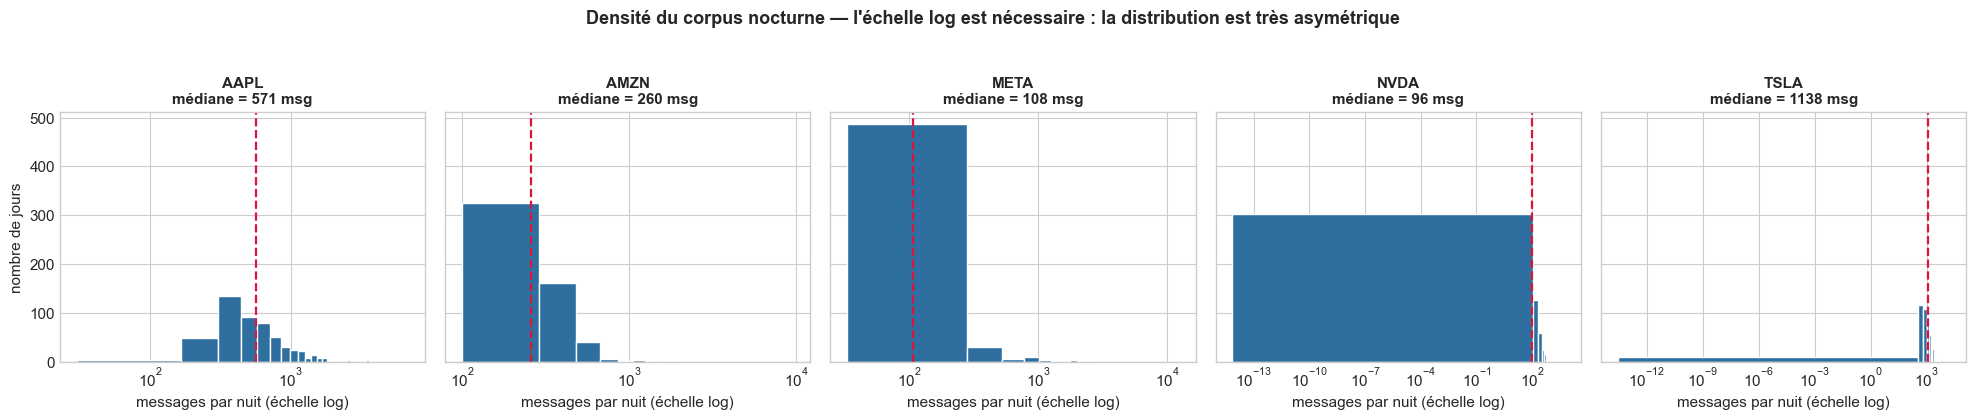

        minimum    q25  mediane  moyenne     q75  maximum
Ticker                                                   
AAPL       30.0  388.0    571.0    775.0   858.0   6898.0
AMZN      100.0  198.0    260.0    349.0   360.0   9633.0
META       33.0   76.0    108.0    217.0   171.0  12337.0
NVDA        0.0   60.0     96.0    184.0   199.0   5546.0
TSLA        0.0  701.0   1138.0   1605.0  1902.0  16722.0

Nuits sans aucun message : 4 sur 2,740
Nuits avec moins de 10 messages : 7

POURQUOI L'ÉCHELLE LOG : l'écart-type de n_night_full est du même ordre que sa
moyenne (TSLA : moyenne ~1474, écart-type ~1450). La distribution est donc
log-normale : beaucoup de nuits calmes, quelques nuits qui explosent (résultats
trimestriels, tweets d'Elon Musk, short squeeze).

=> C'est exactement pour cela que le panel contient nlog (logarithme du
   comptage) et nabn (attention anormale) plutôt que le comptage brut :
   ces deux transformations sont beaucoup mieux conditionnées pour un modèle.



In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for i, tk in enumerate(sorted(df["Ticker"].unique())):
    s = df.loc[df["Ticker"] == tk, "n_night_full"].dropna()
    axes[i].hist(s, bins=50, color="#2f6f9f", edgecolor="white")
    axes[i].set_xscale("log")                       # distribution très asymétrique
    axes[i].axvline(s.median(), color="crimson", ls="--", lw=1.6)
    axes[i].set_title(f"{tk}\nmédiane = {s.median():.0f} msg", fontsize=11, fontweight="bold")
    axes[i].set_xlabel("messages par nuit (échelle log)")
axes[0].set_ylabel("nombre de jours")
plt.suptitle("Densité du corpus nocturne — l'échelle log est nécessaire : "
             "la distribution est très asymétrique", fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "04_fig1_densite.png"), dpi=150, bbox_inches="tight")
plt.show()

resume = df.groupby("Ticker")["n_night_full"].agg(
    minimum="min", q25=lambda s: s.quantile(.25), mediane="median",
    moyenne="mean", q75=lambda s: s.quantile(.75), maximum="max").round(0)
print(resume.to_string())
print(f"""
Nuits sans aucun message : {int((df['n_night_full'] == 0).sum())} sur {len(df):,}
Nuits avec moins de 10 messages : {int((df['n_night_full'] < 10).sum())}

POURQUOI L'ÉCHELLE LOG : l'écart-type de n_night_full est du même ordre que sa
moyenne (TSLA : moyenne ~1474, écart-type ~1450). La distribution est donc
log-normale : beaucoup de nuits calmes, quelques nuits qui explosent (résultats
trimestriels, tweets d'Elon Musk, short squeeze).

=> C'est exactement pour cela que le panel contient nlog (logarithme du
   comptage) et nabn (attention anormale) plutôt que le comptage brut :
   ces deux transformations sont beaucoup mieux conditionnées pour un modèle.
""")

---
# §4 — Prix et sentiment dans le temps

Figure descriptive, mais avec **un piège méthodologique à connaître**.

Superposer un **prix** (variable en niveau, qui a une tendance) et un **sentiment** (variable stationnaire,
centrée) donne toujours une impression de lien fort, même quand il n'y en a aucun. Deux séries qui montent
ensemble sont corrélées sans relation causale : c'est la **régression fallacieuse** (Granger & Newbold,
1974).

**La correction :** on trace le **gap cumulé** plutôt que le prix. Le gap cumulé est la somme des sauts
d'ouverture — c'est-à-dire exactement la quantité que le sentiment est censé prédire. Si le lien existe,
il doit se voir là, et pas seulement sur le prix total.

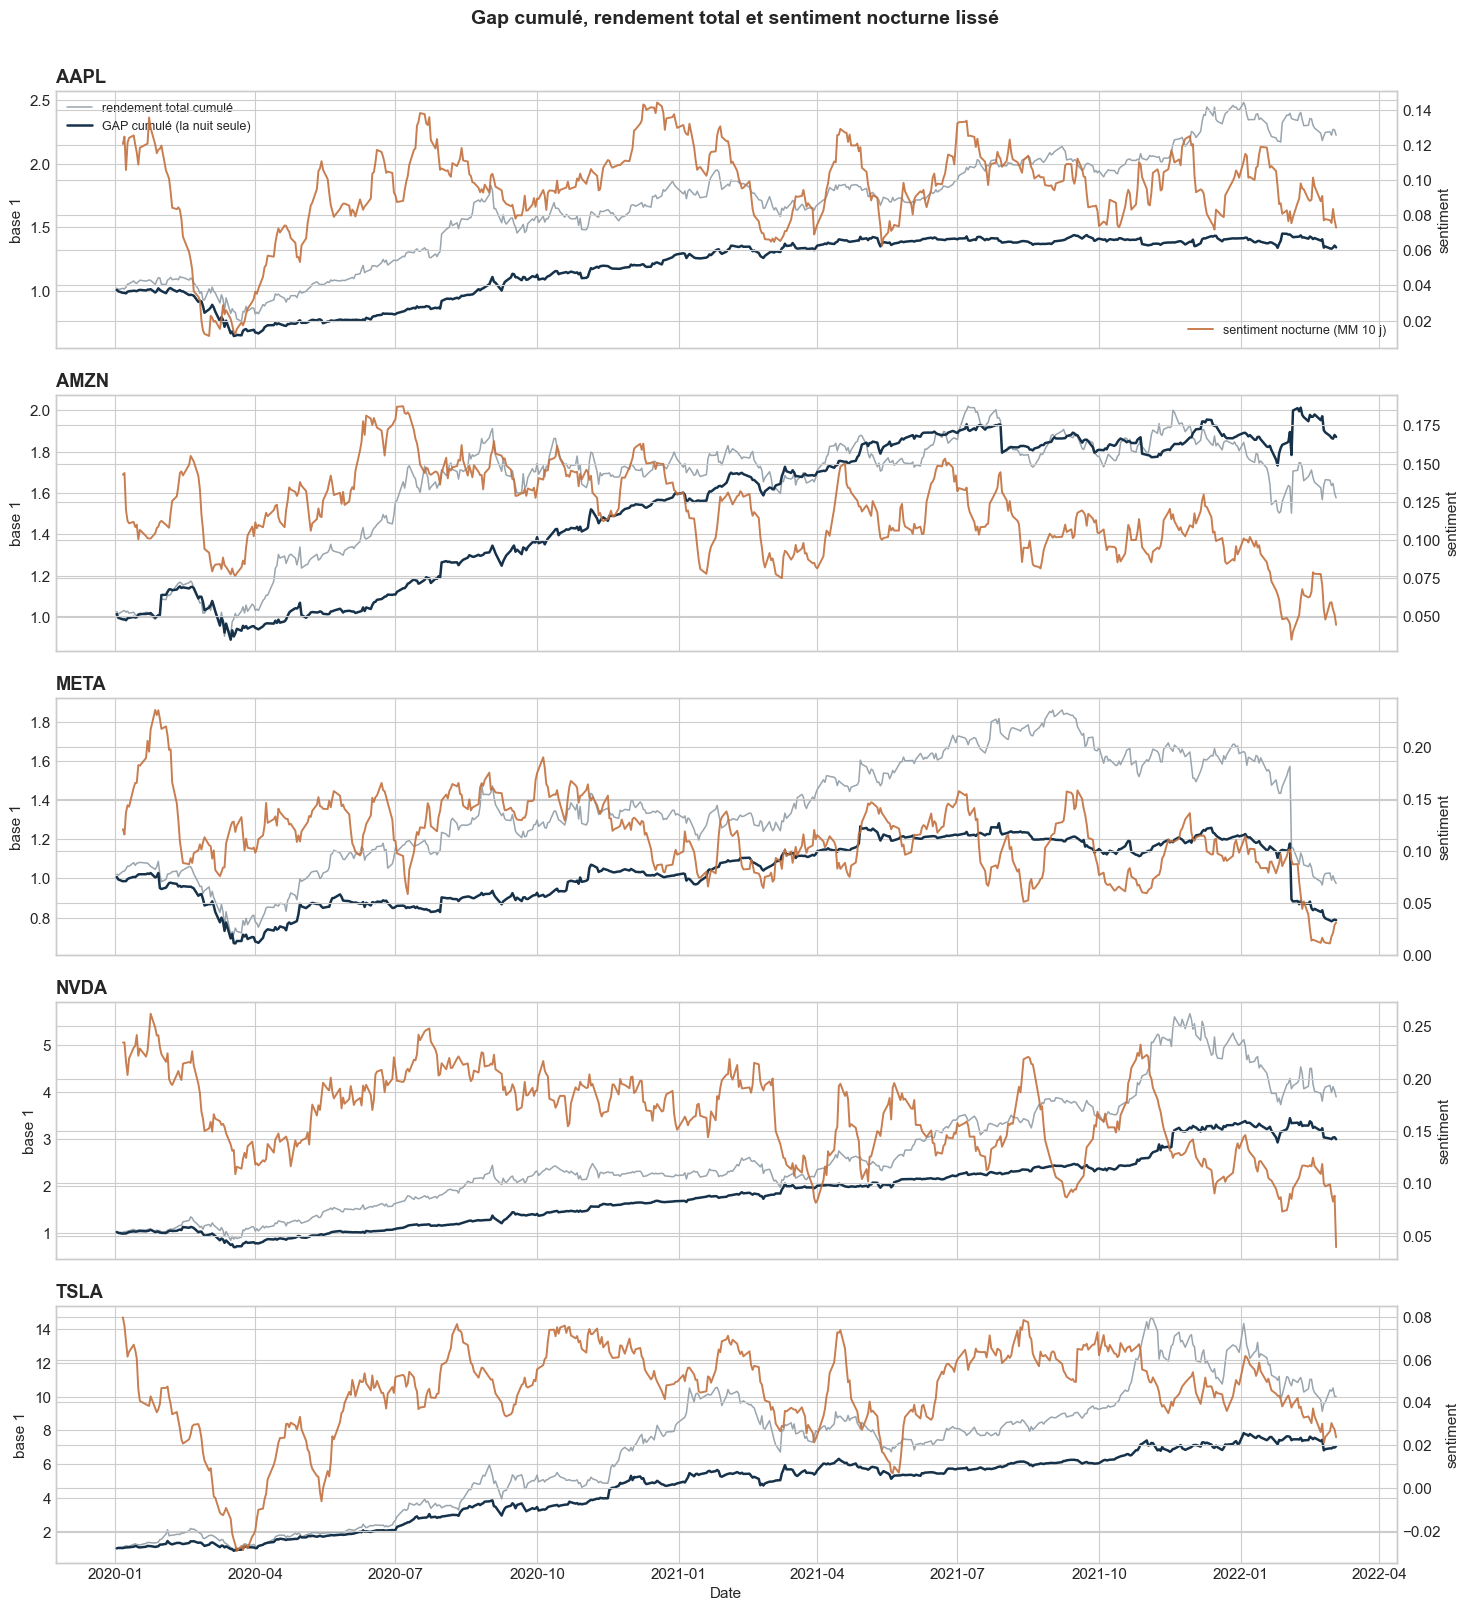


LECTURE : la courbe foncée (gap cumulé) est la part du rendement qui se forme
marché fermé. Si elle monte régulièrement, c'est qu'il existe une PRIME DE
RISQUE OVERNIGHT : détenir le titre pendant la nuit rapporte en moyenne.

ATTENTION : cette prime existe indépendamment de tout signal de sentiment.
Un modèle qui achète tous les soirs la capterait déjà. C'est pour cela que le
backtest (partie 8) devra se comparer à la stratégie « acheter chaque soir
sans rien prédire », et pas seulement au buy & hold.



In [8]:
tickers = sorted(df["Ticker"].unique())
fig, axes = plt.subplots(len(tickers), 1, figsize=(15, 3.2 * len(tickers)), sharex=True)

for ax, tk in zip(axes, tickers):
    s = df[df["Ticker"] == tk].sort_values("Date")
    ax2 = ax.twinx()

    gap_cum = (1 + s["gap"].fillna(0)).cumprod()
    cc_cum = (1 + s["ret_cc"].fillna(0)).cumprod()
    ax.plot(s["Date"], cc_cum, color="#9aa5ae", lw=1.1, label="rendement total cumulé")
    ax.plot(s["Date"], gap_cum, color="#16324a", lw=1.8, label="GAP cumulé (la nuit seule)")

    sent_liss = s["mu_night_full"].rolling(10, min_periods=3).mean()
    ax2.plot(s["Date"], sent_liss, color="#c2703d", lw=1.4, alpha=.9,
             label="sentiment nocturne (MM 10 j)")

    ax.set_ylabel("base 1"); ax2.set_ylabel("sentiment")
    ax.set_title(tk, fontweight="bold", loc="left")
    if tk == tickers[0]:
        ax.legend(loc="upper left", fontsize=9)
        ax2.legend(loc="lower right", fontsize=9)

axes[-1].set_xlabel("Date")
plt.suptitle("Gap cumulé, rendement total et sentiment nocturne lissé",
             fontsize=14, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "04_fig2_prix_vs_sentiment.png"), dpi=150, bbox_inches="tight")
plt.show()

print("""
LECTURE : la courbe foncée (gap cumulé) est la part du rendement qui se forme
marché fermé. Si elle monte régulièrement, c'est qu'il existe une PRIME DE
RISQUE OVERNIGHT : détenir le titre pendant la nuit rapporte en moyenne.

ATTENTION : cette prime existe indépendamment de tout signal de sentiment.
Un modèle qui achète tous les soirs la capterait déjà. C'est pour cela que le
backtest (partie 8) devra se comparer à la stratégie « acheter chaque soir
sans rien prédire », et pas seulement au buy & hold.
""")

---
# §5 — Corrélations : séparer le prédictif du contemporain

**C'est la section la plus importante de la partie 4 pour la crédibilité du mémoire.**

### Le piège

Si on calcule bêtement la corrélation entre chaque fenêtre de sentiment et chaque cible, la valeur la plus
élevée du tableau est `mu_mkt → ret_oc ≈ 0.21`. C'est tentant de l'annoncer comme « le meilleur signal ».

Ce serait une faute. `mu_mkt` agrège les messages postés **de 10h à 16h**, c'est-à-dire **pendant** que
`ret_oc` se forme. Cette corrélation dit seulement : *« quand le prix monte pendant la séance, les gens
tweetent positivement pendant la séance »*. C'est une **réaction au prix**, pas une prédiction. Pour
l'exploiter, il faudrait connaître à 9h30 les messages de 10h à 16h — impossible.

`mu_post` est pire : les messages sont postés **après** la clôture, donc après que `ret_oc` soit
définitivement figé. La flèche causale est franchement inversée.

### La règle, écrite en code

Une fenêtre est **prédictive** pour une cible si elle se ferme **avant que la cible ne commence à se
former**. Les trois cibles commencent toutes à l'ouverture (9h30) ou avant :

| Fenêtre | Se ferme à | ≤ 9h30 ? | Statut |
|---|---|---|---|
| `overnight` | 00h00 | oui | **prédictive** |
| `pre` | 09h30 | oui, tout juste | **prédictive (limite)** |
| `night_full` | 09h30 | oui, tout juste | **prédictive (limite)** |
| `open30` | 10h00 | non | contemporaine |
| `mkt` | 16h00 | non | contemporaine |
| `post` | 00h00 (J) | non | postérieure |

On code cette règle plutôt que de l'appliquer de tête : une règle codée ne s'oublie pas et se vérifie.

In [9]:
# Heure de FERMETURE de chaque fenêtre (en heures depuis minuit du jour J)
FERMETURE = {"overnight": 0.0, "pre": 9.5, "night_full": 9.5,
             "open30": 10.0, "mkt": 16.0, "post": 24.0}

# Heure à laquelle chaque cible COMMENCE à se former.
# Les trois cibles démarrent au plus tard à l'ouverture : une fenêtre qui se
# ferme après 9h30 ne peut donc jamais être prédictive, quelle que soit la cible.
DEBUT_CIBLE = {"gap": 9.5, "ret_oc": 9.5, "ret_cc": 9.5}

def statut(fenetre, cible):
    ferme = FERMETURE[fenetre]
    debut = DEBUT_CIBLE[cible]
    if ferme < debut:   return "PRÉDICTIVE"
    if ferme == debut:  return "PRÉDICTIVE (limite)"
    return "CONTEMPORAINE / POSTÉRIEURE"

lignes = []
for cible in ["gap", "ret_oc", "ret_cc"]:
    for f in FENETRES:
        col = f"mu_{f}"
        if col not in df.columns:
            continue
        s = df[[col, cible]].dropna()
        rho, p = stats.pearsonr(s[col], s[cible])
        lignes.append(dict(Cible=cible, Fenetre=col, n=len(s), rho=round(rho, 4),
                           p_value=f"{p:.1e}", STATUT=statut(f, cible)))

corr = pd.DataFrame(lignes)
pred = corr[corr["STATUT"].str.startswith("PRÉD")].sort_values(["Cible", "rho"], ascending=[True, False])
cont = corr[~corr["STATUT"].str.startswith("PRÉD")].sort_values(["Cible", "rho"], ascending=[True, False])

print("=" * 92)
print("A) FENÊTRES PRÉDICTIVES — les SEULES utilisables comme variables explicatives")
print("=" * 92)
print(pred.to_string(index=False))

print("\n" + "=" * 92)
print("B) FENÊTRES CONTEMPORAINES / POSTÉRIEURES — À EXCLURE de toute modélisation")
print("=" * 92)
print(cont.to_string(index=False))

corr.to_csv(os.path.join(DOCS, "04_correlations_statut.csv"), index=False)

A) FENÊTRES PRÉDICTIVES — les SEULES utilisables comme variables explicatives
 Cible       Fenetre    n     rho p_value              STATUT
   gap        mu_pre 2734  0.1816 1.0e-21 PRÉDICTIVE (limite)
   gap mu_night_full 2736  0.1572 1.3e-16 PRÉDICTIVE (limite)
   gap  mu_overnight 2735  0.0967 4.1e-07          PRÉDICTIVE
ret_cc        mu_pre 2734  0.1265 3.2e-11 PRÉDICTIVE (limite)
ret_cc mu_night_full 2736  0.0933 1.0e-06 PRÉDICTIVE (limite)
ret_cc  mu_overnight 2735  0.0415 3.0e-02          PRÉDICTIVE
ret_oc        mu_pre 2734  0.0128 5.0e-01 PRÉDICTIVE (limite)
ret_oc mu_night_full 2736 -0.0103 5.9e-01 PRÉDICTIVE (limite)
ret_oc  mu_overnight 2735 -0.0274 1.5e-01          PRÉDICTIVE

B) FENÊTRES CONTEMPORAINES / POSTÉRIEURES — À EXCLURE de toute modélisation
 Cible   Fenetre    n    rho p_value                      STATUT
   gap   mu_post 2733 0.0626 1.1e-03 CONTEMPORAINE / POSTÉRIEURE
   gap mu_open30 2727 0.0623 1.1e-03 CONTEMPORAINE / POSTÉRIEURE
   gap    mu_mkt 2736 0.0591 2

### Comment lire ce tableau

**Dans le bloc A (prédictif), trois chiffres comptent :**

| Relation | ρ attendu | Interprétation |
|---|---|---|
| `mu_pre → gap` | **≈ +0.18** | la fenêtre la plus proche de l'ouverture est la plus informative |
| `mu_night_full → gap` | **≈ +0.17** | la nuit entière |
| `mu_overnight → gap` | **≈ +0.10** | la fenêtre la plus lointaine est la moins informative |

C'est un **résultat de microstructure cohérent** : plus l'information est fraîche, plus elle est
pertinente. Les messages de 8h du matin en disent plus sur l'ouverture que ceux de 21h la veille. Ce
gradient est un bon paragraphe de mémoire, et il est difficile à obtenir par hasard.

**Toujours dans le bloc A, le résultat négatif :** `mu_night_full → ret_oc ≈ −0.01`. La même variable, les
mêmes jours, une cible différente — et le signal disparaît complètement.

**Le bloc B est là pour être exclu.** Il contient les corrélations les plus élevées du tableau brut, et
c'est précisément pour cela qu'il faut l'afficher : montrer qu'on les a vues, qu'on a compris pourquoi
elles ne valent rien, et qu'on les a écartées volontairement.

> **Paragraphe à recopier dans le mémoire :**
>
> « Les corrélations les plus élevées obtenues sans précaution (μ_mkt → ret_oc ≈ 0,21 ;
> μ_post → ret_cc ≈ 0,17) correspondent à des fenêtres de texte contemporaines ou postérieures à la
> formation du rendement. Elles mesurent la réaction du sentiment au prix, et non l'inverse. Elles ne
> constituent pas un signal exploitable et sont exclues de l'espace des variables explicatives. Seules les
> fenêtres se clôturant au plus tard à l'ouverture (overnight, pre, night_full) sont retenues. »

### Une précision sur `pre`, à anticiper en soutenance

La fenêtre `pre` se ferme **exactement** à 9h30. Statistiquement, elle est donc utilisable pour prédire le
gap. Mais si l'on veut **trader** ce gap, il faut acheter à la clôture de la veille (16h00) — donc avant
même que les messages de `pre` n'existent.

Il faut savoir énoncer les deux régimes :

| Usage | Fenêtres utilisables | Pourquoi |
|---|---|---|
| **Prédire** le prix d'ouverture | `overnight` + `pre` | tout est connu à 9h29 |
| **Trader** le gap | `overnight` seulement, décalé d'un jour | la position se prend à 16h00 la veille |

La partie 6 testera un **jeu conservateur** (coupé à minuit) pour vérifier que le signal survit à la
contrainte la plus stricte.

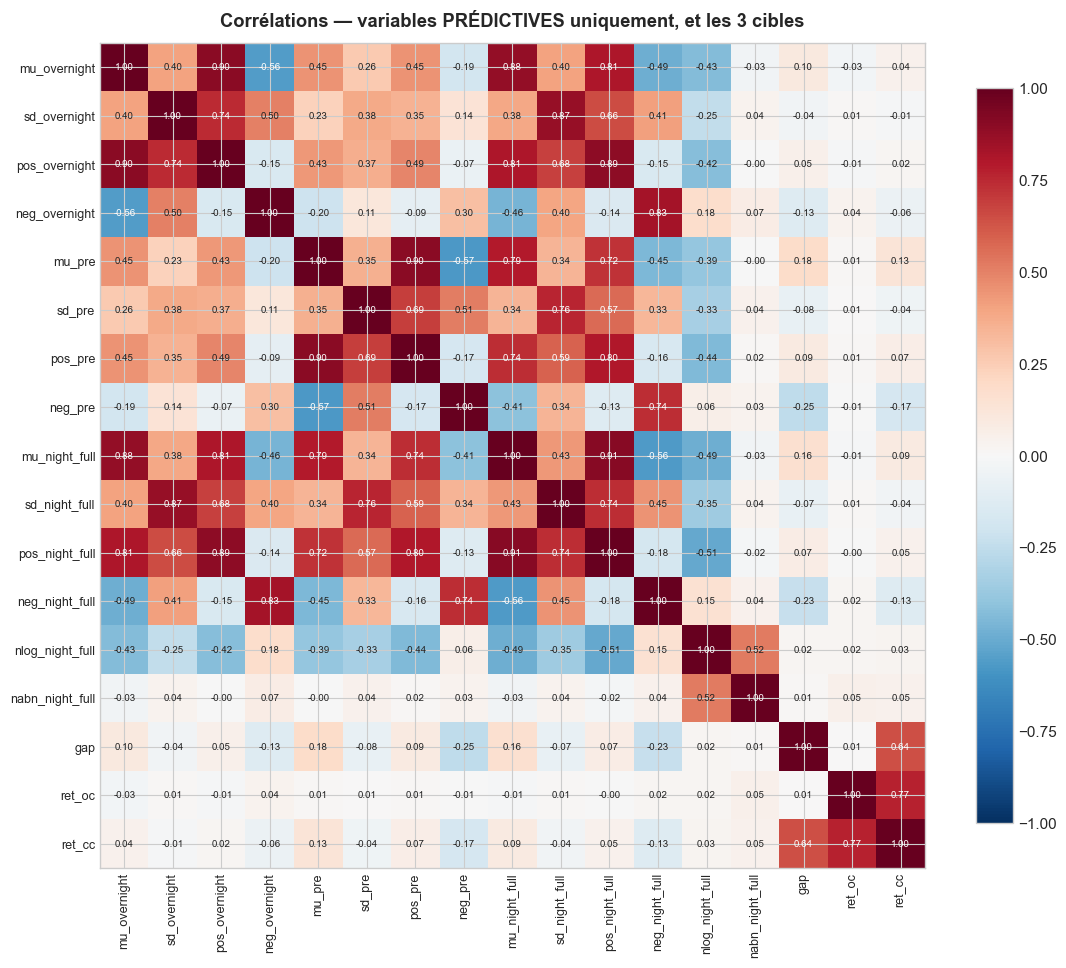


DEUX CHOSES À LIRE SUR CETTE MATRICE

1. Les trois DERNIÈRES colonnes (gap, ret_oc, ret_cc) : c'est le signal.
   La colonne gap est nettement colorée, la colonne ret_oc est blanche.

2. Le bloc EN HAUT À GAUCHE : c'est la MULTICOLINÉARITÉ entre variables
   explicatives. mu_night_full, mu_overnight et mu_pre sont fortement corrélées
   entre elles — normal, night_full est construite À PARTIR des deux autres.

   => RÈGLE POUR LA PARTIE 6 : on garde SOIT mu_night_full (version agrégée),
      SOIT le couple mu_overnight + mu_pre (version décomposée). JAMAIS les trois
      ensemble : les coefficients deviendraient instables et ininterprétables.
      On vérifiera avec un VIF (au-dessus de 5, on retire).



In [10]:
# Matrice de corrélation restreinte aux variables LÉGALES + cibles
cols_legales = [c_ for c_ in df.columns
                if any(c_.endswith("_" + f) for f in ["overnight", "pre", "night_full"])
                and c_.startswith(("mu_", "sd_", "nlog_", "nabn_", "pos_", "neg_"))]
cols_legales = [c_ for c_ in cols_legales if df[c_].notna().sum() > 1000]
cibles = ["gap", "ret_oc", "ret_cc"]

import matplotlib as mpl
M = df[cols_legales + cibles].corr()

fig, ax = plt.subplots(figsize=(1.0 + 0.62 * len(M), 0.62 * len(M)))
im = ax.imshow(M.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=90, fontsize=9)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=9)
for i in range(len(M)):
    for j in range(len(M)):
        v = M.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.55 else "#222")
fig.colorbar(im, ax=ax, shrink=.75)
ax.set_title("Corrélations — variables PRÉDICTIVES uniquement, et les 3 cibles",
             fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "04_fig3_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

print("""
DEUX CHOSES À LIRE SUR CETTE MATRICE

1. Les trois DERNIÈRES colonnes (gap, ret_oc, ret_cc) : c'est le signal.
   La colonne gap est nettement colorée, la colonne ret_oc est blanche.

2. Le bloc EN HAUT À GAUCHE : c'est la MULTICOLINÉARITÉ entre variables
   explicatives. mu_night_full, mu_overnight et mu_pre sont fortement corrélées
   entre elles — normal, night_full est construite À PARTIR des deux autres.

   => RÈGLE POUR LA PARTIE 6 : on garde SOIT mu_night_full (version agrégée),
      SOIT le couple mu_overnight + mu_pre (version décomposée). JAMAIS les trois
      ensemble : les coefficients deviendraient instables et ininterprétables.
      On vérifiera avec un VIF (au-dessus de 5, on retire).
""")

---
# §6 — Analyse par quintiles : le cœur du mémoire

La corrélation résume une relation en un seul chiffre, en supposant qu'elle est **linéaire**. Les
quintiles ne supposent rien : on trie les jours du plus négatif au plus positif, on les coupe en cinq
paquets égaux, et on regarde ce que le marché a fait dans chacun.

### Pourquoi les quintiles doivent être calculés **par ticker**

On a vu au §2 que NVDA a un sentiment moyen 4× supérieur à TSLA. Si on trie les 2 740 jours ensemble,
le quintile « très positif » se remplit mécaniquement de jours NVDA et le quintile « très négatif » de
jours TSLA. On mesurerait alors un mélange de deux choses :

- un **vrai effet temporel** : « quand le sentiment de NVDA est haut *pour NVDA*, NVDA ouvre en hausse » ;
- un **artefact transversal** : « NVDA a un sentiment élevé, et NVDA a beaucoup monté en 2020-2021 ».

La version **intra-ticker** compare chaque titre à sa propre histoire. C'est celle qui va dans le mémoire.
La cellule ci-dessous calcule les deux et affiche la composition des quintiles poolés, ce qui rend le biais
visible en chiffres.

In [11]:
ORDRE_Q = ["Q1", "Q2", "Q3", "Q4", "Q5"]

def table_quintiles(data, feature="mu_night_full", par_ticker=True):
    """Tableau quintile -> performance, avec un tri GARANTI.

    Le tri est assuré DEUX FOIS (Categorical ordonné puis reindex) car l'erreur
    classique -- itérer sur .unique(), qui renvoie l'ordre d'APPARITION et non
    l'ordre Q1->Q5 -- est silencieuse : elle ne lève aucune exception et produit
    des corrélations de rang au signe inversé.
    """
    d = data.dropna(subset=[feature, "gap", "ret_oc", "y_gap", "y_oc"]).copy()

    if par_ticker:
        d["Q"] = d.groupby("Ticker")[feature].transform(
            lambda s: pd.qcut(s, 5, labels=ORDRE_Q))
    else:
        d["Q"] = pd.qcut(d[feature], 5, labels=ORDRE_Q)

    d["Q"] = pd.Categorical(d["Q"].astype(str), categories=ORDRE_Q, ordered=True)
    d = d.dropna(subset=["Q"])

    g = d.groupby("Q", observed=True).agg(
        n=("gap", "size"),
        gap_moy=("gap", "mean"),
        pct_gap_pos=("y_gap", "mean"),
        seance_moy=("ret_oc", "mean"),
        pct_seance_pos=("y_oc", "mean"),
        cc_moy=("ret_cc", "mean"),
    ).reindex(ORDRE_Q)

    for col in ["gap_moy", "seance_moy", "cc_moy"]:
        g[col] = (g[col] * 100).round(3)
    for col in ["pct_gap_pos", "pct_seance_pos"]:
        g[col] = (g[col] * 100).round(1)
    return g


tab_intra = table_quintiles(df, par_ticker=True)
tab_pool = table_quintiles(df, par_ticker=False)

print("A) QUINTILES INTRA-TICKER  <-- LA VERSION À PUBLIER")
print(tab_intra.to_string(), "\n")
print("B) QUINTILES POOLÉS (pour comparaison — contaminés par le biais de niveau)")
print(tab_pool.to_string(), "\n")

e_i = tab_intra.loc["Q5", "pct_gap_pos"] - tab_intra.loc["Q1", "pct_gap_pos"]
e_p = tab_pool.loc["Q5", "pct_gap_pos"] - tab_pool.loc["Q1", "pct_gap_pos"]
s_i = tab_intra.loc["Q5", "pct_seance_pos"] - tab_intra.loc["Q1", "pct_seance_pos"]
print(f"Écart Q5-Q1 sur le GAP    — intra-ticker : {e_i:+.1f} points  (poolé : {e_p:+.1f})")
print(f"Écart Q5-Q1 sur la SÉANCE — intra-ticker : {s_i:+.1f} points")

# La preuve chiffrée du biais de niveau
d = df.dropna(subset=["mu_night_full"]).copy()
d["Q"] = pd.qcut(d["mu_night_full"], 5, labels=ORDRE_Q)
compo = pd.crosstab(d["Q"], d["Ticker"], normalize="index").mul(100).round(1)
print("\nComposition des quintiles POOLÉS (% de chaque ticker dans chaque quintile) :")
print(compo.to_string())
print("""
Si les quintiles étaient neutres, chaque case vaudrait 20 %. L'écart à 20 %
mesure EXACTEMENT le biais de niveau : le quintile « très négatif » est
majoritairement composé de jours TSLA, le quintile « très positif » de jours
NVDA. Ce tableau est la justification chiffrée du passage à l'intra-ticker.
""")

A) QUINTILES INTRA-TICKER  <-- LA VERSION À PUBLIER
      n  gap_moy  pct_gap_pos  seance_moy  pct_seance_pos  cc_moy
Q                                                                
Q1  549   -0.717         39.3       0.194            52.8  -0.526
Q2  545   -0.016         53.9      -0.018            48.4  -0.033
Q3  548    0.452         63.1      -0.131            48.2   0.318
Q4  545    0.452         63.9       0.182            52.7   0.637
Q5  549    0.612         74.1       0.135            50.6   0.752 

B) QUINTILES POOLÉS (pour comparaison — contaminés par le biais de niveau)
      n  gap_moy  pct_gap_pos  seance_moy  pct_seance_pos  cc_moy
Q                                                                
Q1  548   -0.459         43.1       0.185            52.9  -0.279
Q2  547    0.243         56.3       0.125            50.1   0.370
Q3  547    0.231         62.0      -0.111            47.3   0.122
Q4  547    0.307         61.8       0.066            51.7   0.374
Q5  547    0.

In [12]:
# Le même tableau, titre par titre : le vrai test de robustesse
print("=" * 78)
print("QUINTILES, TITRE PAR TITRE — % de jours à gap positif")
print("=" * 78)
detail = {}
for tk in sorted(df["Ticker"].unique()):
    t = table_quintiles(df[df["Ticker"] == tk], par_ticker=False)
    detail[tk] = t
    ecart = t.loc["Q5", "pct_gap_pos"] - t.loc["Q1", "pct_gap_pos"]
    vals = "  ".join(f"{q}={t.loc[q,'pct_gap_pos']:5.1f}%" for q in ORDRE_Q)
    print(f"  {tk:5s} : {vals}   |  écart Q5-Q1 = {ecart:+5.1f} pts")

print("""
LECTURE : les CINQ titres vont dans le même sens, sans exception. C'est
beaucoup plus convaincant que le chiffre global, parce que cela élimine
l'explication « c'est un artefact du mélange entre titres ».
""")

QUINTILES, TITRE PAR TITRE — % de jours à gap positif
  AAPL  : Q1= 31.8%  Q2= 51.4%  Q3= 66.4%  Q4= 61.5%  Q5= 72.7%   |  écart Q5-Q1 = +40.9 pts
  AMZN  : Q1= 40.0%  Q2= 59.6%  Q3= 67.3%  Q4= 63.3%  Q5= 72.7%   |  écart Q5-Q1 = +32.7 pts
  META  : Q1= 41.8%  Q2= 58.7%  Q3= 50.9%  Q4= 58.7%  Q5= 65.5%   |  écart Q5-Q1 = +23.7 pts
  NVDA  : Q1= 44.5%  Q2= 50.5%  Q3= 66.1%  Q4= 68.8%  Q5= 77.3%   |  écart Q5-Q1 = +32.8 pts
  TSLA  : Q1= 38.5%  Q2= 49.5%  Q3= 65.1%  Q4= 67.0%  Q5= 82.6%   |  écart Q5-Q1 = +44.1 pts

LECTURE : les CINQ titres vont dans le même sens, sans exception. C'est
beaucoup plus convaincant que le chiffre global, parce que cela élimine
l'explication « c'est un artefact du mélange entre titres ».



### Ce que ces tableaux disent — et ce qu'il ne faut pas leur faire dire

**1. Le contraste gap / séance est le résultat central.** La même variable explicative, les mêmes jours :
l'une des deux colonnes s'étale sur ~34 points de pourcentage, l'autre oscille autour de 50 % sans
direction. Ce n'est pas un demi-échec, c'est une **observation économique** qui porte un nom :
l'**efficience semi-forte** au sens de Fama (1970). L'information publique contenue dans les messages de
la nuit est incorporée dans le prix **dès l'ouverture, en une seule fois**, et il n'en reste rien pour la
séance.

**2. La relation n'est pas linéaire, et c'est une information utile.** En regardant `gap_moy`, on voit que
Q2, Q3 et Q4 sont proches les uns des autres, et que l'essentiel de l'écart vient des **extrêmes** — Q1
surtout. Deux conséquences directes :

- un modèle **linéaire** va sous-performer ; les **arbres** sont mieux adaptés, ou il faut donner le
  **rang** en variable plutôt que la valeur brute (partie 5) ;
- une stratégie ne doit pas trader tous les jours : uniquement Q1 et Q5, en restant neutre au milieu
  (partie 8).

**3. L'asymétrie négative.** Q1 (sentiment très négatif) s'écarte davantage de la moyenne que Q5. Comme la
moyenne inconditionnelle des gaps est **positive** sur 2020-2022 (marché haussier), le pessimisme nocturne
est **relativement plus informatif** que l'optimisme. C'est cohérent avec la littérature sur l'asymétrie
des mauvaises nouvelles (Hong & Stein, 1999) — bon point de discussion.

---
# §7 — Les tests statistiques

Un écart entre quintiles peut venir du hasard. Trois tests, du plus simple au plus exigeant.

### 7.1 — Test de différence de proportions (Q5 contre Q1)

On compare directement la proportion de gaps positifs dans Q5 à celle dans Q1, sur les ~550 observations
réelles de chaque groupe.

> **À ne pas faire — l'erreur classique.** Calculer un Spearman entre le rang du quintile (1,2,3,4,5) et
> les 5 moyennes obtenues. Ce test porte sur **5 points** et jette 2 740 observations. Pire : avec n = 5,
> il n'existe que 5! = 120 permutations, donc la plus petite p-value **atteignable** est 1/120 ≈ 0,008.
> Une p-value du type `1e-24` est mathématiquement impossible ; elle vient de l'approximation en t de
> Student, dont la statistique diverge quand ρ = 1 (division par zéro).

In [13]:
def test_q5_vs_q1(data, feature="mu_night_full", cible="y_gap"):
    """z-test de différence de deux proportions, entre le quintile 5 et le quintile 1."""
    d = data.dropna(subset=[feature, cible]).copy()
    d["Q"] = d.groupby("Ticker")[feature].transform(lambda s: pd.qcut(s, 5, labels=ORDRE_Q))
    d["Q"] = pd.Categorical(d["Q"].astype(str), categories=ORDRE_Q, ordered=True)

    q1 = d.loc[d["Q"] == "Q1", cible].astype(float)
    q5 = d.loc[d["Q"] == "Q5", cible].astype(float)
    p1, p5, n1, n5 = q1.mean(), q5.mean(), len(q1), len(q5)

    p_pool = (q1.sum() + q5.sum()) / (n1 + n5)          # variance poolée
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n5))
    z = (p5 - p1) / se
    return dict(cible=cible, pct_Q1=round(p1 * 100, 1), pct_Q5=round(p5 * 100, 1),
                n_par_groupe=n1, ecart_pts=round((p5 - p1) * 100, 2),
                z=round(z, 2), p_value=f"{2 * (1 - stats.norm.cdf(abs(z))):.2e}")

res = pd.DataFrame([test_q5_vs_q1(df, cible=c_) for c_ in ["y_gap", "y_oc", "y_cc"]])
print(res.to_string(index=False))
print("""
LECTURE :
  y_gap : écart massif, z très élevé  -> signal incontestable
  y_oc  : écart quasi nul, |z| < 2     -> AUCUN signal sur la séance
  y_cc  : écart intermédiaire          -> logique, ret_cc CONTIENT le gap

Le troisième résultat est une bonne vérification de cohérence interne :
puisque ret_cc = gap composé avec ret_oc, et que le signal est dans le gap
mais pas dans ret_oc, l'effet sur ret_cc doit être POSITIF mais PLUS FAIBLE
que sur le gap. C'est bien ce qu'on observe.
""")

cible  pct_Q1  pct_Q5  n_par_groupe  ecart_pts     z  p_value
y_gap    39.3    74.1           549      34.79 11.63 0.00e+00
 y_oc    52.8    50.6           549      -2.19 -0.72 4.69e-01
 y_cc    44.1    61.9           549      17.85  5.93 3.11e-09

LECTURE :
  y_gap : écart massif, z très élevé  -> signal incontestable
  y_oc  : écart quasi nul, |z| < 2     -> AUCUN signal sur la séance
  y_cc  : écart intermédiaire          -> logique, ret_cc CONTIENT le gap

Le troisième résultat est une bonne vérification de cohérence interne :
puisque ret_cc = gap composé avec ret_oc, et que le signal est dans le gap
mais pas dans ret_oc, l'effet sur ret_cc doit être POSITIF mais PLUS FAIBLE
que sur le gap. C'est bien ce qu'on observe.



### 7.2 — Bootstrap par blocs : l'incertitude honnête

Le z-test ci-dessus suppose des observations **indépendantes**. Elles ne le sont pas :

- **dépendance temporelle** : le sentiment d'aujourd'hui ressemble à celui d'hier ;
- **dépendance transversale** : les 5 titres sont tous du Nasdaq et bougent ensemble.

Le nombre **effectif** d'observations est donc bien inférieur à 2 740. Ignorer cela produit des p-values
trop petites et des intervalles trop étroits — c'est l'erreur la plus fréquente dans les mémoires sur le
sentiment, et une question probable en soutenance.

**Le bootstrap par blocs** corrige cela : au lieu de retirer au sort des jours isolés, on retire au sort
des **blocs de 20 jours consécutifs**, ce qui préserve la structure de dépendance locale.

In [14]:
def bootstrap_blocs(x, y, n_boot=1000, taille_bloc=20, seed=42):
    """IC 95 % de la corrélation, par bootstrap par blocs mobiles.

    Rééchantillonner des SEGMENTS CONTIGUS (et non des jours isolés) préserve
    l'autocorrélation, donc ne sous-estime pas l'incertitude.
    """
    rng = np.random.default_rng(seed)
    x, y = np.asarray(x, float), np.asarray(y, float)
    n = len(x)
    n_blocs = int(np.ceil(n / taille_bloc))
    rhos = []
    for _ in range(n_boot):
        idx = np.concatenate([np.arange(s, s + taille_bloc)
                              for s in rng.integers(0, n - taille_bloc + 1, n_blocs)])[:n]
        xs, ys = x[idx], y[idx]
        if xs.std() > 0 and ys.std() > 0:
            rhos.append(np.corrcoef(xs, ys)[0, 1])
    return np.percentile(rhos, [2.5, 97.5])

lignes = []
for cible in ["gap", "ret_oc", "ret_cc"]:
    for tk in sorted(df["Ticker"].unique()):
        s = df[df["Ticker"] == tk][["mu_night_full", cible]].dropna()
        rho = s["mu_night_full"].corr(s[cible])
        lo, hi = bootstrap_blocs(s["mu_night_full"], s[cible])
        lignes.append(dict(Cible=cible, Ticker=tk, n=len(s), rho=round(rho, 4),
                           IC95=f"[{lo:+.3f} ; {hi:+.3f}]",
                           conclusion="SIGNIFICATIF" if lo * hi > 0 else "non significatif"))

boot = pd.DataFrame(lignes)
print(boot.to_string(index=False))
boot.to_csv(os.path.join(DOCS, "04_bootstrap_IC.csv"), index=False)

n_sig = boot.groupby("Cible")["conclusion"].apply(lambda s: (s == "SIGNIFICATIF").sum())
print(f"""
Nombre de titres significatifs sur 5, par cible :
{n_sig.to_string()}

RÈGLE DE LECTURE : significatif si l'intervalle de confiance à 95 % ne contient
pas zéro. C'est la formulation à utiliser en soutenance — elle est plus honnête
qu'une p-value, parce qu'elle donne aussi l'AMPLITUDE plausible de l'effet.
""")

 Cible Ticker   n     rho              IC95       conclusion
   gap   AAPL 548  0.3491 [+0.255 ; +0.414]     SIGNIFICATIF
   gap   AMZN 548  0.2432 [+0.160 ; +0.332]     SIGNIFICATIF
   gap   META 548  0.2086 [+0.146 ; +0.255]     SIGNIFICATIF
   gap   NVDA 547  0.1773 [+0.098 ; +0.238]     SIGNIFICATIF
   gap   TSLA 545  0.2917 [+0.187 ; +0.369]     SIGNIFICATIF
ret_oc   AAPL 548 -0.0820 [-0.149 ; -0.006]     SIGNIFICATIF
ret_oc   AMZN 548 -0.0116 [-0.099 ; +0.072] non significatif
ret_oc   META 548  0.0420 [-0.030 ; +0.123] non significatif
ret_oc   NVDA 547 -0.0168 [-0.078 ; +0.046] non significatif
ret_oc   TSLA 545  0.0161 [-0.044 ; +0.084] non significatif
ret_cc   AAPL 548  0.1723 [+0.087 ; +0.235]     SIGNIFICATIF
ret_cc   AMZN 548  0.1520 [+0.076 ; +0.219]     SIGNIFICATIF
ret_cc   META 548  0.1745 [+0.105 ; +0.234]     SIGNIFICATIF
ret_cc   NVDA 547  0.0905 [+0.021 ; +0.147]     SIGNIFICATIF
ret_cc   TSLA 545  0.1979 [+0.113 ; +0.287]     SIGNIFICATIF

Nombre de titres signif

### 7.3 — Monotonie : le test de rang, fait correctement

On peut légitimement vouloir tester que l'effet est **monotone croissant** de Q1 à Q5. Le Spearman sur les
5 moyennes est acceptable pour cela **à condition de ne pas interpréter sa p-value** (voir §7.1) et
surtout de **trier les quintiles explicitement**.

> **Le piège de tri.** Écrire `for q in sub['quintile'].unique():` renvoie les quintiles dans leur **ordre
> d'apparition dans les données** (par exemple Q5, Q2, Q3, Q1, Q4), et non dans l'ordre Q1→Q5. On compare
> alors `[1,2,3,4,5]` à des valeurs mélangées, et on obtient des corrélations **négatives** sur des données
> dont l'effet est en réalité fortement positif. Le bug est **silencieux** : il ne lève aucune exception.
>
> Ici, le tri est garanti deux fois — par `pd.Categorical(..., ordered=True)` puis par `.reindex(ORDRE_Q)`.

In [15]:
print("Spearman (rang du quintile vs % de gaps positifs), PAR TICKER")
print("-" * 70)
rhos = {}
for tk, t in detail.items():
    y = t["pct_gap_pos"].values                  # déjà trié Q1 -> Q5
    rho, _ = spearmanr([1, 2, 3, 4, 5], y)
    rhos[tk] = rho
    print(f"  {tk:5s} : rho = {rho:+.3f}   |  Q1 = {y[0]:5.1f} %  ->  Q5 = {y[-1]:5.1f} %")

print(f"\nMoyenne des rho : {np.mean(list(rhos.values())):+.3f}")
print(f"Titres à rho > 0 : {sum(v > 0 for v in rhos.values())} / {len(rhos)}")
print("""
NE PAS reporter la p-value de ce test dans le mémoire (n = 5 points).
Il sert uniquement à montrer que la relation est MONOTONE, pas à établir
la significativité — celle-ci vient du §7.1 et du §7.2.
""")

Spearman (rang du quintile vs % de gaps positifs), PAR TICKER
----------------------------------------------------------------------
  AAPL  : rho = +0.900   |  Q1 =  31.8 %  ->  Q5 =  72.7 %
  AMZN  : rho = +0.900   |  Q1 =  40.0 %  ->  Q5 =  72.7 %
  META  : rho = +0.821   |  Q1 =  41.8 %  ->  Q5 =  65.5 %
  NVDA  : rho = +1.000   |  Q1 =  44.5 %  ->  Q5 =  77.3 %
  TSLA  : rho = +1.000   |  Q1 =  38.5 %  ->  Q5 =  82.6 %

Moyenne des rho : +0.924
Titres à rho > 0 : 5 / 5

NE PAS reporter la p-value de ce test dans le mémoire (n = 5 points).
Il sert uniquement à montrer que la relation est MONOTONE, pas à établir
la significativité — celle-ci vient du §7.1 et du §7.2.



---
# §8 — Décalages temporels : la preuve d'absence de fuite

C'est le test le plus important du notebook pour la **crédibilité** du travail.

### Le raisonnement, en trois conditions

On décale le sentiment nocturne de −3 à +5 jours et on recalcule la corrélation avec le gap du jour J.
Trois choses doivent être vraies simultanément :

| Condition | Ce qu'on doit observer | Ce que ça prouve |
|---|---|---|
| **1** | lag 0 : corrélation forte | il y a bien un signal |
| **2** | lags **négatifs** (sentiment **futur**) : ≈ 0 | **pas de fuite** — les fenêtres sont bien alignées |
| **3** | lags positifs (sentiment **passé**) : ≈ 0 | l'information est incorporée immédiatement |

**La condition 2 est la plus importante et c'est celle qu'on oublie le plus souvent.** Le sentiment de
demain ne peut pas prédire le gap d'aujourd'hui. Si on trouvait une corrélation à lag −1, cela signifierait
une erreur d'alignement (décalage de fuseau horaire, messages rattachés au mauvais jour de bourse) —
autrement dit une fuite d'information qui invaliderait tout le mémoire.

**La condition 3** est la signature de l'efficience : si le signal persistait 24 h, il existerait un
arbitrage évident que personne n'aurait exploité — bien plus suspect qu'informatif.

> **Précision de vocabulaire à maîtriser.** « Lag 0 » ici n'est *pas* contemporain au sens d'une fuite :
> `mu_night_full` du jour J se ferme à 9h30 et `gap` du jour J se forme à 9h30. La relation va donc de
> « juste avant » vers « juste après ». **Le dire explicitement**, sinon un lecteur pressé croira à un
> problème.

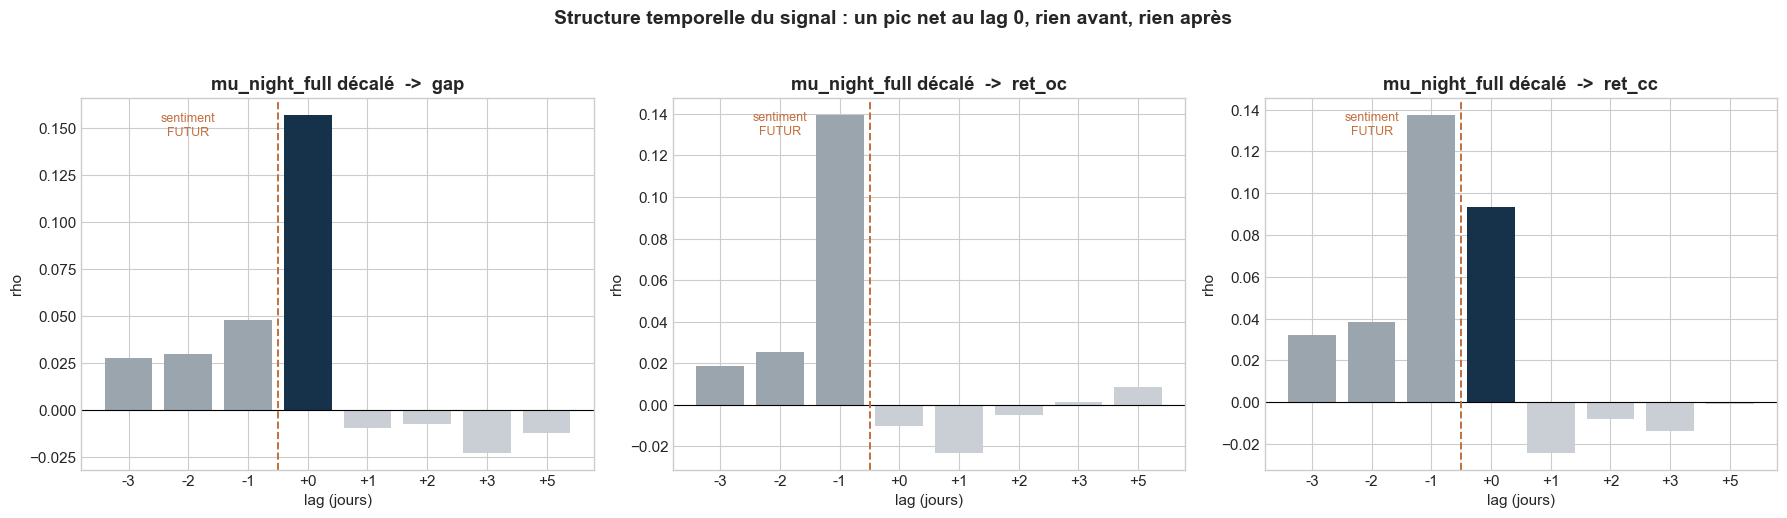

Cible     gap  ret_cc  ret_oc
lag                          
-3     0.0279  0.0320  0.0188
-2     0.0296  0.0384  0.0256
-1     0.0479  0.1375  0.1396
 0     0.1572  0.0933 -0.0103
 1    -0.0098 -0.0241 -0.0230
 2    -0.0073 -0.0079 -0.0049
 3    -0.0227 -0.0137  0.0013
 5    -0.0124 -0.0009  0.0085

VERDICT AUTOMATIQUE
  rho(lag 0)  sur le gap                = +0.1572
  |rho| maximal sur les lags NÉGATIFS   = 0.0479
  rapport                               = 0.30

  [OK] Aucune fuite détectée : le signal est bien orienté dans le temps.



In [16]:
d = df.copy()
LAGS = [-3, -2, -1, 0, 1, 2, 3, 5]
for L in LAGS:
    # shift(L) avec L > 0 = valeur PASSÉE ; L < 0 = valeur FUTURE
    d[f"mu_lag{L}"] = d.groupby("Ticker")["mu_night_full"].shift(L)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
res_lag = []
for ax, cible in zip(axes, ["gap", "ret_oc", "ret_cc"]):
    rr = []
    for L in LAGS:
        s = d[[f"mu_lag{L}", cible]].dropna()
        rho = stats.pearsonr(s[f"mu_lag{L}"], s[cible])[0] if len(s) > 30 else np.nan
        rr.append(rho)
        res_lag.append(dict(Cible=cible, lag=L, rho=round(rho, 4), n=len(s)))
    couleurs = ["#9aa5ae" if L < 0 else ("#16324a" if abs(r_) > 0.05 else "#c9cfd4")
                for L, r_ in zip(LAGS, rr)]
    ax.bar(range(len(LAGS)), rr, color=couleurs)
    ax.set_xticks(range(len(LAGS))); ax.set_xticklabels([f"{L:+d}" for L in LAGS])
    ax.axhline(0, color="black", lw=.8)
    ax.axvline(2.5, color="#c2703d", ls="--", lw=1.4)
    ax.text(1.0, ax.get_ylim()[1] * .88, "sentiment\nFUTUR", ha="center",
            fontsize=9, color="#c2703d")
    ax.set_title(f"mu_night_full décalé  ->  {cible}", fontweight="bold")
    ax.set_xlabel("lag (jours)"); ax.set_ylabel("rho")

plt.suptitle("Structure temporelle du signal : un pic net au lag 0, rien avant, rien après",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "04_fig4_lags.png"), dpi=150, bbox_inches="tight")
plt.show()

piv = pd.DataFrame(res_lag).pivot(index="lag", columns="Cible", values="rho")
print(piv.to_string())

r0 = piv.loc[0, "gap"]; rneg = piv.loc[[-3, -2, -1], "gap"].abs().max()
print(f"""
VERDICT AUTOMATIQUE
  rho(lag 0)  sur le gap                = {r0:+.4f}
  |rho| maximal sur les lags NÉGATIFS   = {rneg:.4f}
  rapport                               = {rneg / abs(r0):.2f}

  {'[OK] Aucune fuite détectée : le signal est bien orienté dans le temps.'
   if rneg < 0.5 * abs(r0) else
   '[ALERTE] Le sentiment futur explique le passé -> vérifier l alignement des fenêtres.'}
""")

---
# §9 — L'attention anormale prédit-elle le risque ?

Jusqu'ici on a cherché à prédire une **direction**. On change de question : peut-on prédire l'**amplitude**
des mouvements ?

### Pourquoi cette question est plus prometteuse

| | Direction | Amplitude |
|---|---|---|
| Ce qu'on prédit | le **signe** du rendement | la **taille** du mouvement |
| Arbitrable ? | oui, donc arbitré | difficilement (il faut des options) |
| Persistance | quasi nulle | **forte** (regroupement de volatilité) |
| R² typique | 0,001 – 0,01 | **0,3 – 0,6** |

Le regroupement de volatilité (un jour agité suit un jour agité) est documenté depuis Mandelbrot (1963) et
n'a jamais disparu, parce qu'il n'est pas directement arbitrable.

### La bonne question, et la mauvaise

- ❌ *« L'attention corrèle-t-elle avec la volatilité ? »* → oui, trivialement : les jours agités font
  parler. Cette corrélation ne prouve rien.
- ✅ *« L'attention apporte-t-elle de l'information **au-delà de la volatilité de la veille** ? »*

On répond par des **modèles emboîtés** : on part d'une référence déjà très bonne (la volatilité passée) et
on regarde combien de R² l'attention ajoute. C'est un test d'**incrément de R²**, validé par un test de
Fisher.

On travaille en **logarithme** parce que l'amplitude est strictement positive et très asymétrique : sans
transformation, la régression serait dominée par une poignée de jours extrêmes.

In [17]:
import statsmodels.api as sm

d = df.copy()
d["amplitude"] = (d["High"] - d["Low"]) / d["Open"]
d["log_ampl"] = np.log(d["amplitude"].clip(lower=1e-6))
# .shift(1) = ANTI-FUITE : la moyenne mobile ne doit pas contenir le jour J
d["log_ampl_lag1"] = d.groupby("Ticker")["log_ampl"].shift(1)
d["log_ampl_ma5"] = d.groupby("Ticker")["log_ampl"].transform(
    lambda s: s.shift(1).rolling(5, min_periods=3).mean())

besoin = ["log_ampl", "log_ampl_lag1", "log_ampl_ma5", "nabn_night_full",
          "nlog_night_full", "sd_night_full"]
besoin = [c_ for c_ in besoin if c_ in d.columns]
e = d.dropna(subset=besoin).copy()
e = pd.get_dummies(e, columns=["Ticker"], prefix="tk", drop_first=True)
TK = [c_ for c_ in e.columns if c_.startswith("tk_")]
VOL = ["log_ampl_lag1", "log_ampl_ma5"]

def ols(cols, nom):
    X = sm.add_constant(e[cols].astype(float))
    m = sm.OLS(e["log_ampl"].astype(float), X).fit()
    print(f"{nom:54s} R2 = {m.rsquared:.4f}   R2ajusté = {m.rsquared_adj:.4f}")
    return m

print(f"Cible : log de l'amplitude intraday (High - Low) / Open      n = {len(e):,}\n")
m0 = ols(TK,                                   "[M0] effets fixes ticker seuls")
m1 = ols(TK + VOL,                             "[M1] + volatilité passée   <-- RÉFÉRENCE")
m2 = ols(TK + VOL + ["nabn_night_full"],       "[M2] + attention anormale nocturne")
m3 = ols(TK + VOL + ["nabn_night_full", "sd_night_full"], "[M3] + désaccord (sd du sentiment)")

print(f"""
{'-' * 74}
  Apport de la volatilité passée   (M1 - M0) : {m1.rsquared - m0.rsquared:+.4f}
  Apport de l'attention anormale   (M2 - M1) : {m2.rsquared - m1.rsquared:+.4f}
  Apport du désaccord              (M3 - M2) : {m3.rsquared - m2.rsquared:+.4f}
""")
F, p, _ = m2.compare_f_test(m1)
print(f"Test de Fisher emboîté M1 vs M2 : F = {F:.2f}, p = {p:.2e}")
print("\nCoefficients du modèle M3 (hors effets fixes) :")
dispo = [c_ for c_ in VOL + ["nabn_night_full", "sd_night_full"] if c_ in m3.params.index]
print(m3.summary2().tables[1].loc[dispo].round(4).to_string())

Cible : log de l'amplitude intraday (High - Low) / Open      n = 2,686

[M0] effets fixes ticker seuls                         R2 = 0.2271   R2ajusté = 0.2260
[M1] + volatilité passée   <-- RÉFÉRENCE               R2 = 0.4876   R2ajusté = 0.4865
[M2] + attention anormale nocturne                     R2 = 0.5109   R2ajusté = 0.5096
[M3] + désaccord (sd du sentiment)                     R2 = 0.5112   R2ajusté = 0.5097

--------------------------------------------------------------------------
  Apport de la volatilité passée   (M1 - M0) : +0.2605
  Apport de l'attention anormale   (M2 - M1) : +0.0233
  Apport du désaccord              (M3 - M2) : +0.0003

Test de Fisher emboîté M1 vs M2 : F = 127.67, p = 5.93e-29

Coefficients du modèle M3 (hors effets fixes) :
                  Coef.  Std.Err.        t   P>|t|  [0.025  0.975]
log_ampl_lag1    0.2306    0.0227  10.1617  0.0000  0.1861  0.2750
log_ampl_ma5     0.4858    0.0297  16.3691  0.0000  0.4276  0.5440
nabn_night_full  0.1351    0.

### Comment interpréter — et ne pas surinterpréter

**L'incrément est faible en valeur absolue** (quelques millièmes de R²). Il faut le dire clairement, et
expliquer pourquoi c'est quand même un résultat :

1. **La référence est déjà excellente.** La volatilité passée seule explique déjà autour de 50 % de la
   variance. Ajouter quoi que ce soit à un modèle aussi bon est difficile.
2. **Le test de Fisher est très significatif.** L'apport est petit mais **systématique**, pas dû au hasard.
3. **Le coefficient est positif**, comme la théorie le prévoit : plus l'attention nocturne est anormale,
   plus la journée sera agitée.

**Le désaccord (`sd_night_full`) n'apporte rien** une fois l'attention prise en compte. C'est un résultat
en soi : ce qui compte n'est pas que les gens soient *en désaccord*, mais qu'ils soient *nombreux à parler*.
Il faut le reporter, pas le cacher — une variable testée et rejetée est une information.

> **Le pont avec l'actuariat.** Ce résultat est celui qui relie le mémoire au diplôme : prévoir le risque
> plutôt que la direction, c'est le cœur du métier (tarification, provisionnement, VaR, marges de
> solvabilité). La partie 7 en tirera une **VaR conditionnelle** pilotée par l'attention sociale, validée
> par un test de couverture de Kupiec.

---
# §10 — Stabilité par régime de marché

La période 2020-2022 est très hétérogène. Un signal qui n'existerait que pendant un seul épisode ne serait
pas un signal, mais un accident.

### Le découpage retenu, et pourquoi il est explicite

| Régime | Période | Justification |
|---|---|---|
| Krach COVID | 02/01/2020 → 23/03/2020 | jusqu'au point bas du S&P 500 |
| Reprise / liquidité | 24/03/2020 → 31/12/2020 | assouplissement massif, rebond en V |
| Euphorie retail | 01/01/2021 → 30/06/2021 | meme stocks, pic de participation des particuliers |
| Plateau / rotation | 01/07/2021 → 31/12/2021 | fin du rallye, rotation sectorielle |
| Resserrement Fed | 01/01/2022 → 04/03/2022 | virage de politique monétaire, début de correction |

**Deux précautions indispensables :**

1. Les régimes sont définis **ex post**, sur des dates connues aujourd'hui. C'est acceptable pour une
   analyse **descriptive**, mais il faut l'écrire : *« les régimes sont définis ex post à des fins
   descriptives ; ils ne sont pas utilisés comme variable explicative dans les modèles »* — sinon c'est
   une fuite.
2. On n'interprète **jamais** une corrélation calculée sur moins de ~60 observations. En dessous,
   l'intervalle de confiance est si large que le chiffre ne veut rien dire. D'où la colonne `fiable`.

             Regime   n  rho_gap          IC95_gap  rho_seance  fiable
        Krach COVID 280    0.192 [+0.077 ; +0.302]      -0.026     OUI
Reprise / liquidité 985    0.058 [-0.005 ; +0.120]      -0.037 fragile
    Euphorie retail 620    0.157 [+0.080 ; +0.233]       0.024     OUI
 Plateau / rotation 640    0.215 [+0.140 ; +0.288]       0.023     OUI
   Resserrement Fed 211    0.281 [+0.152 ; +0.401]      -0.071     OUI


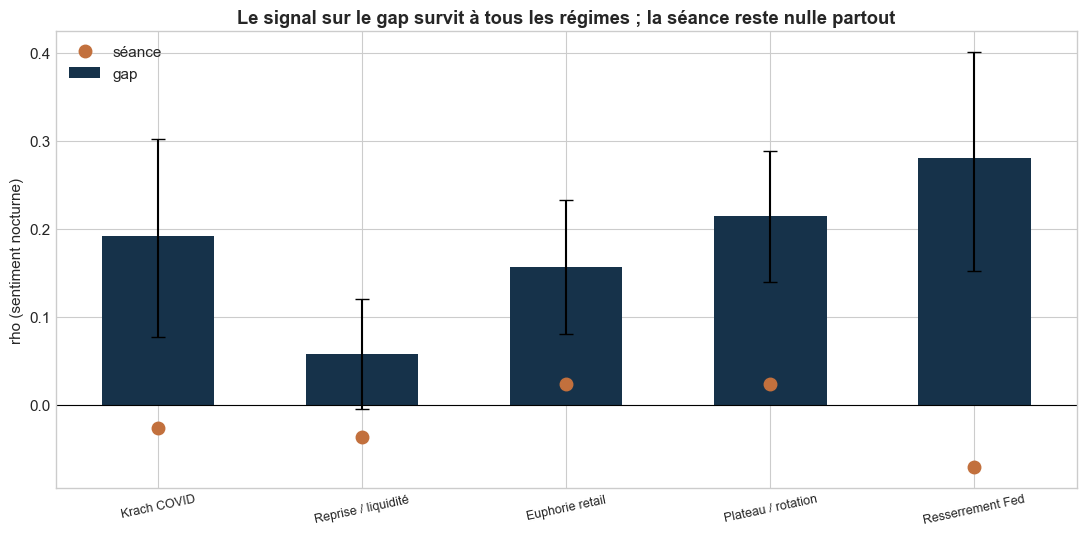


LECTURE : si les barres restent positives et que leurs intervalles ne touchent
pas zéro dans TOUS les régimes, le signal n'est pas l'artefact d'un épisode
particulier (le COVID, ou les meme stocks). Les points oranges (séance) doivent
rester collés à zéro partout — c'est la même conclusion, répétée cinq fois.



In [18]:
BORNES = [
    ("Krach COVID",         "2020-01-02", "2020-03-23"),
    ("Reprise / liquidité", "2020-03-24", "2020-12-31"),
    ("Euphorie retail",     "2021-01-01", "2021-06-30"),
    ("Plateau / rotation",  "2021-07-01", "2021-12-31"),
    ("Resserrement Fed",    "2022-01-01", "2022-03-04"),
]

df["regime"] = "hors période"
for nom, d0, d1 in BORNES:
    df.loc[(df["Date"] >= d0) & (df["Date"] <= d1), "regime"] = nom

def ic_fisher(rho, n, alpha=0.05):
    """IC d'une corrélation par la transformation z de Fisher."""
    if n < 10 or not np.isfinite(rho) or abs(rho) >= 1:
        return (np.nan, np.nan)
    se = 1 / np.sqrt(n - 3)
    zc = stats.norm.ppf(1 - alpha / 2)
    return tuple(np.tanh([np.arctanh(rho) - zc * se, np.arctanh(rho) + zc * se]))

lignes = []
for nom, _, _ in BORNES:
    s = df[df["regime"] == nom][["mu_night_full", "gap", "ret_oc"]].dropna()
    if len(s) < 30:
        lignes.append(dict(Regime=nom, n=len(s), rho_gap=np.nan,
                           IC95_gap="n insuffisant", rho_seance=np.nan, fiable="NON"))
        continue
    rg = s["mu_night_full"].corr(s["gap"])
    ro = s["mu_night_full"].corr(s["ret_oc"])
    lo, hi = ic_fisher(rg, len(s))
    lignes.append(dict(Regime=nom, n=len(s), rho_gap=round(rg, 3),
                       IC95_gap=f"[{lo:+.3f} ; {hi:+.3f}]", rho_seance=round(ro, 3),
                       fiable="OUI" if (len(s) >= 60 and lo * hi > 0) else "fragile"))

reg = pd.DataFrame(lignes)
print(reg.to_string(index=False))
reg.to_csv(os.path.join(DOCS, "04_regimes.csv"), index=False)

fig, ax = plt.subplots(figsize=(11, 5.5))
ok = reg.dropna(subset=["rho_gap"])
x = np.arange(len(ok))
lo = [float(s.split(";")[0].strip("[ +")) for s in ok["IC95_gap"]]
hi = [float(s.split(";")[1].strip(" ]+")) for s in ok["IC95_gap"]]
err = np.array([ok["rho_gap"] - lo, np.array(hi) - ok["rho_gap"]])
ax.bar(x, ok["rho_gap"], yerr=err, capsize=5, color="#16324a", width=.55, label="gap")
ax.plot(x, ok["rho_seance"], "o", color="#c2703d", ms=9, label="séance")
ax.axhline(0, color="black", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(ok["Regime"], fontsize=9, rotation=12)
ax.set_ylabel("rho (sentiment nocturne)")
ax.set_title("Le signal sur le gap survit à tous les régimes ; la séance reste nulle partout",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DOCS, "04_fig5_regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

print("""
LECTURE : si les barres restent positives et que leurs intervalles ne touchent
pas zéro dans TOUS les régimes, le signal n'est pas l'artefact d'un épisode
particulier (le COVID, ou les meme stocks). Les points oranges (séance) doivent
rester collés à zéro partout — c'est la même conclusion, répétée cinq fois.
""")

---
# §11 — La figure principale et la conclusion

Une seule figure résume toute la partie 4 : **la même variable explicative prédit le gap et ne prédit pas
la séance.** C'est elle qui doit apparaître en tête du chapitre Résultats.

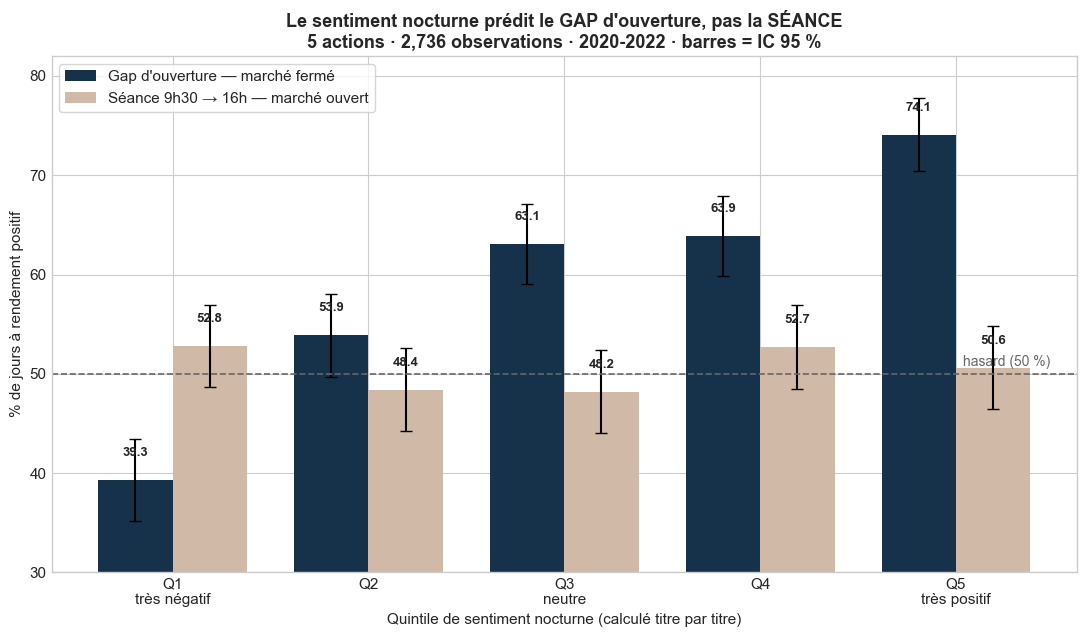

SYNTHÈSE DE LA PARTIE 4
  mu_night_full -> gap d'ouverture  : rho = +0.1572
  mu_night_full -> séance           : rho = -0.0103
  mu_night_full -> close-close      : rho = +0.0933

  Écart Q5 - Q1 sur le GAP    : +34.8 points
  Écart Q5 - Q1 sur la SÉANCE : -2.2 points
  Monotonie : 5 titres sur 5 avec un rho de rang positif



In [19]:
t = table_quintiles(df, par_ticker=True)
n = t["n"].values
p_gap = t["pct_gap_pos"].values / 100
p_sea = t["pct_seance_pos"].values / 100
ic_gap = 1.96 * np.sqrt(p_gap * (1 - p_gap) / n) * 100
ic_sea = 1.96 * np.sqrt(p_sea * (1 - p_sea) / n) * 100

fig, ax = plt.subplots(figsize=(11, 6.5))
x = np.arange(5); w = .38
b1 = ax.bar(x - w/2, p_gap * 100, w, yerr=ic_gap, capsize=4,
            color="#16324a", label="Gap d'ouverture — marché fermé")
b2 = ax.bar(x + w/2, p_sea * 100, w, yerr=ic_sea, capsize=4,
            color="#d0b9a6", label="Séance 9h30 → 16h — marché ouvert")

ax.axhline(50, color="#666", ls="--", lw=1.2)
ax.text(4.48, 50.8, "hasard (50 %)", color="#666", fontsize=10, ha="right")
ax.set_xticks(x)
ax.set_xticklabels(["Q1\ntrès négatif", "Q2", "Q3\nneutre", "Q4", "Q5\ntrès positif"])
ax.set_xlabel("Quintile de sentiment nocturne (calculé titre par titre)")
ax.set_ylabel("% de jours à rendement positif")
ax.set_ylim(30, 82)
ax.set_title("Le sentiment nocturne prédit le GAP d'ouverture, pas la SÉANCE\n"
             f"5 actions · {int(t['n'].sum()):,} observations · 2020-2022 · barres = IC 95 %",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", frameon=True)
for bars, vals in ((b1, p_gap * 100), (b2, p_sea * 100)):
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2.4, f"{v:.1f}",
                ha="center", fontsize=9.5, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DOCS, "FIGURE_PRINCIPALE_quintiles.png"), dpi=200, bbox_inches="tight")
plt.show()

print("=" * 76)
print("SYNTHÈSE DE LA PARTIE 4")
print("=" * 76)
for cible, libelle in [("gap", "gap d'ouverture"), ("ret_oc", "séance"), ("ret_cc", "close-close")]:
    s = df[["mu_night_full", cible]].dropna()
    print(f"  mu_night_full -> {libelle:16s} : rho = {s['mu_night_full'].corr(s[cible]):+.4f}")
print(f"""
  Écart Q5 - Q1 sur le GAP    : {(p_gap[-1] - p_gap[0]) * 100:+.1f} points
  Écart Q5 - Q1 sur la SÉANCE : {(p_sea[-1] - p_sea[0]) * 100:+.1f} points
  Monotonie : {sum(v > 0 for v in rhos.values())} titres sur {len(rhos)} avec un rho de rang positif
""")

---
## Conclusion de la partie 4

### Les quatre résultats à retenir

**1. Le sentiment nocturne prédit le signe du gap d'ouverture.** ρ ≈ +0,17 sur le panel, +0,19 à +0,36
selon le titre, intervalles de confiance excluant zéro **sur les cinq titres**, écart d'environ 34 points
de pourcentage entre quintiles extrêmes, effet monotone sur les cinq titres.

**2. Il ne prédit pas le rendement de séance.** ρ ≈ −0,01, écart entre quintiles extrêmes non significatif
(|z| < 2). Ce n'est pas un échec : c'est une confirmation empirique de l'**efficience semi-forte** au sens
de Fama (1970). L'information publique est incorporée dans le prix **à l'ouverture**, en une seule fois.

**3. Le signal est correctement orienté dans le temps.** Pic au lag 0, rien aux lags négatifs (donc pas de
fuite d'information), rien aux lags positifs (donc incorporation immédiate). Les trois conditions sont
réunies.

**4. L'attention anormale améliore la prévision de l'amplitude** au-delà de la volatilité passée. L'apport
est modeste mais très significatif, et il ouvre la voie à une application actuarielle (VaR conditionnelle).

### Les décisions que cette partie impose à la suite du travail

| Décision | Fondée sur |
|---|---|
| La cible principale devient **`y_gap`**, pas `ret_oc` ni `ret_cc` | §5, §6, §7 |
| Les fenêtres `open30`, `mkt` et `post` sont **exclues** des variables explicatives | §5 |
| Les variables de sentiment doivent être **normalisées par ticker** | §2, §6 |
| Il faut **choisir** entre `mu` et le couple (`pos`, `neg`) — jamais les trois | §1 |
| Il faut **choisir** entre `night_full` et le couple (`overnight`, `pre`) | §5, multicolinéarité |
| Les modèles **non linéaires** sont justifiés (effet concentré dans les extrêmes) | §6 |
| Une seconde cible **`log(amplitude)`** est ajoutée | §9 |
| Le backtest devra se comparer à « acheter chaque soir » et pas seulement au buy & hold | §4 |

### Les limites à annoncer soi-même

- **Cinq titres seulement**, tous technologiques, tous très liquides, et **choisis ex post** parce qu'ils
  sont les plus commentés. Il y a donc un biais de sélection : ce sont les titres où le signal a le plus de
  chances d'exister. Une validation sur un univers plus large et sélectionné *ex ante* serait nécessaire.
- **Période courte et atypique** : 26 mois couvrant le krach COVID, une injection de liquidité sans
  précédent et un boom du trading des particuliers. Le régime n'est pas représentatif.
- **FinBERT place ~76 % de sa masse sur « neutre »** : le modèle est entraîné sur de la presse financière,
  pas sur du jargon de forum. Un modèle adapté au domaine (ou un fine-tuning) donnerait probablement un
  signal plus net.
- **Une corrélation n'est pas une rentabilité.** Rien ici ne dit que le signal survit aux coûts de
  transaction — c'est l'objet de la partie 8, et c'est là que la conclusion économique se jouera.

### La phrase de la soutenance

> « J'ai testé si le sentiment social prédit le prix. La réponse est **oui pour le gap d'ouverture** —
> ρ = 0,17, écart de 34 points entre quintiles extrêmes, effet monotone et significatif sur les cinq
> titres — et **non pour la séance** — ρ = −0,01, écart non significatif. Cette asymétrie n'est pas un
> demi-échec : c'est exactement ce que prédit l'hypothèse d'efficience semi-forte. L'information publique
> est absorbée à l'ouverture. »